<a href="https://colab.research.google.com/github/Pavitra-B-Kochalapur/FedEx-Logistic-Analysis/blob/master/FedEX_Logistics_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Name -** FedEx Logistics Performance Analysis - Exploratory Data Analysis

**Project Type -** EDA

**Contribution -** Individual

**Name -** Pavitra K

**Project Summary -**

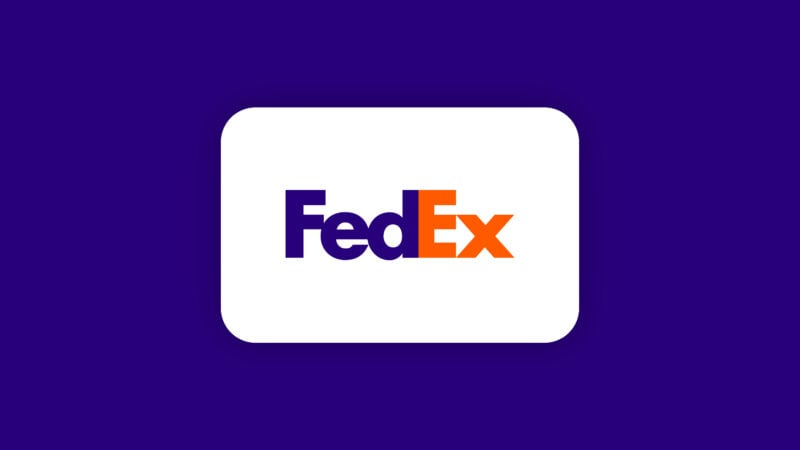

FedEx is one of the world’s largest and most trusted logistics and transportation companies, known for its global express shipping network, innovation in supply chain solutions, and commitment to reliable, time-bound delivery services. Operating across more than 220 countries and territories, FedEx manages millions of shipments every day through a complex ecosystem of air, ground, and freight operations. In such a vast and high-velocity logistics environment, performance monitoring is essential to ensure on-time delivery, cost efficiency, and continuous improvement. This project, FedEx Logistics Performance Analysis, focuses on evaluating key operational metrics that influence delivery reliability, shipping cost structures, vendor efficiency, and overall supply chain effectiveness.

The dataset provided contains detailed shipment history information such as delivery-related dates, freight charges, weight, product descriptions, vendors, shipment modes, and route destinations. These data points enable a comprehensive assessment of FedEx’s logistics performance from request generation to final delivery. The goal of this analysis is to transform the dataset into meaningful insights that reflect service quality, operational bottlenecks, cost drivers, and shipment trends.

To prepare the dataset for analysis, several data cleaning and transformation steps were performed. Date fields with inconsistent or non-standard entries were standardized and converted into proper datetime formats. Numerical columns such as freight cost and weight, which may contain text-based inconsistencies, were cleaned and cast into usable numeric types. New variables were engineered to capture logistics KPIs—such as lead times between procurement stages, schedule delays, delivery timeliness, cost per kilogram, freight-to-commodity value ratios, and monthly or yearly time indicators. These transformed metrics allow for robust comparisons and trend analysis across routes, vendors, shipment modes, and product categories.

The core of this project centers on evaluating FedEx’s logistics KPIs across four major dimensions:

Service Performance: On-time delivery rate, average lead time, delay duration, and timeliness score provide insights into service reliability. These KPIs help identify countries or regions where FedEx faces delivery challenges and shipment modes that consistently perform better or worse.

Cost Efficiency: Logistics cost analysis includes total freight spend, freight cost per kilogram, and freight cost as a proportion of total shipment value. These metrics reveal how efficiently FedEx manages transportation costs and highlight potential optimization opportunities, such as evaluating weight-based cost disparities or high-cost vendor relationships.

Shipment Volume and Operational Load: Trends in shipment counts, total quantity delivered, and monthly shipment value reflect workload distribution and seasonal demand patterns. This analysis helps identify peak periods, route congestion, and capacity planning requirements within FedEx’s operations.

Vendor, Route, and Product Performance: Vendor-wise performance indicators reveal whether certain partners contribute to delays or higher freight costs. Country and route-level analysis exposes geographic challenges and opportunities. Product-level insights, based on product group or classification, show which items drive the most value, weight, or complexity within the logistics chain.

Visualizations—including interactive time series plots, cost vs. performance scatter charts, boxplots for lead times by shipment mode, bar charts for country-wise KPIs, and distribution analyses—translate the dataset into intuitive, decision-ready insights. Correlation heatmaps further uncover relationships between freight cost, value, weight, and delivery timelines.

Overall, this project provides a detailed and data-driven evaluation of FedEx’s logistics performance, highlighting areas of operational excellence along with systemic inefficiencies. By turning raw shipment data into actionable insights, the analysis supports strategic decision-making for improving delivery reliability, optimizing freight costs, strengthening vendor management, and enhancing FedEx’s global supply chain efficiency. This performance analysis ultimately reinforces FedEx’s mission to deliver every shipment with speed, accuracy, and guaranteed reliability.

**Problem Statement**

FedEx manages a high volume of global shipments, making it essential to continuously evaluate logistics performance to ensure timely deliveries and cost-efficient operations. However, variations in delivery times, freight costs, vendor performance, and shipment modes can create inefficiencies that impact service quality and operational expenses. This project aims to analyze historical shipment data to identify delays, cost drivers, performance gaps, and operational trends within FedEx’s logistics network. By transforming raw delivery records into actionable KPIs, the analysis seeks to uncover patterns affecting reliability and efficiency. The ultimate objective is to provide data-driven insights that support strategic decision-making and improve FedEx’s overall logistics performance.

**Define Your Business Objective?**

The primary objective of this project is to evaluate FedEx’s logistics performance using historical shipment data to identify operational inefficiencies and areas for improvement. By analyzing delivery timelines, freight costs, shipment modes, and vendor performance, the goal is to uncover patterns that influence service reliability and cost-effectiveness. This analysis aims to generate meaningful KPIs that measure lead times, on-time delivery rates, and logistics cost efficiency across regions and product categories. Insights from the study will help FedEx optimize transportation strategies, reduce delays, lower operational costs, and enhance customer satisfaction. Ultimately, the objective is to support data-driven decision-making for strengthening FedEx’s global supply chain operations.

**Let's Begin !**

**1. Know Your Data**

Import Libraries


In [37]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Dataset Loading**

In [38]:
fedex_df = pd.read_csv('/content/SCMS_Delivery_History_Dataset.csv')
print('The dataset has been loaded')

The dataset has been loaded


**Dataset First View**

In [39]:
# Dataset First Look
fedex_df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2-Jun-06,2-Jun-06,2-Jun-06,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,14-Nov-06,14-Nov-06,14-Nov-06,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,Pre-PQ Process,Date Not Captured,27-Aug-06,27-Aug-06,27-Aug-06,HRDT,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,1-Sep-06,1-Sep-06,1-Sep-06,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,11-Aug-06,11-Aug-06,11-Aug-06,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


In [40]:
pd.set_option('display.max_columns', None)
fedex_df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2-Jun-06,2-Jun-06,2-Jun-06,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,14-Nov-06,14-Nov-06,14-Nov-06,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,Pre-PQ Process,Date Not Captured,27-Aug-06,27-Aug-06,27-Aug-06,HRDT,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,1-Sep-06,1-Sep-06,1-Sep-06,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,11-Aug-06,11-Aug-06,11-Aug-06,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


**Dataset Rows & Columns count**

In [41]:
# Dataset Rows & Columns count
fedex_df.shape

(10324, 33)

**Dataset Information**

In [42]:
# Dataset Info
fedex_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

**Duplicate Values**

In [43]:
# Dataset Duplicate Value Count
fedex_df.duplicated().sum()

np.int64(0)

**Missing Values/Null Values**

In [44]:
# Missing Values/Null Values Count
fedex_df.isnull().sum()

,0
ID,0
Project Code,0
PQ #,0
PO / SO #,0
ASN/DN #,0
Country,0
Managed By,0
Fulfill Via,0
Vendor INCO Term,0
Shipment Mode,360


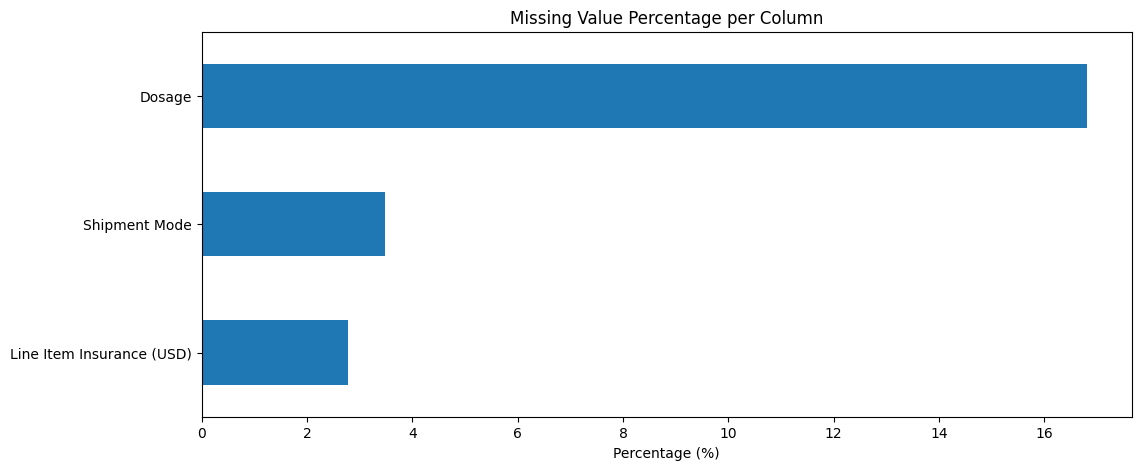

In [45]:
# Visualizing the missing values
missing = fedex_df.isnull().mean() *100
missing = missing[missing > 0]

plt.figure(figsize=(12,5))
missing.sort_values().plot(kind='barh')
plt.title("Missing Value Percentage per Column")
plt.xlabel("Percentage (%)")
plt.show()

**What did you know about your dataset?**

Our dataset has 10324 rows and 33 columns. There are 0 duplicate values in our dataset. There are 360 null values in the 'Shipment mode' column of the dataset, 1736 null values in the 'Dosage' column and 287 null values in the 'Line Item Insurance (USD)' column of the dataset.

**2. Understanding Your Variables**

In [46]:
# Dataset Columns
fedex_df.columns

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')

In [47]:
# Dataset Describe
fedex_df.describe(include='all')

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
count,10324.000000,10324,10324,10324,10324,10324,10324,10324,10324,9964,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,8588,10324,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10324,10324,10324,10324,10037.000000
unique,NaN,142,1237,6233,7030,43,4,2,8,4,765,897,2006,2093,2042,5,6,73,184,86,48,54,17,NaN,NaN,NaN,NaN,NaN,88,2,4688,6733,NaN
top,NaN,116-ZA-T30,Pre-PQ Process,SCMS-199289,ASN-19166,South Africa,PMO - US,From RDC,N/A - From RDC,Air,Pre-PQ Process,N/A - From RDC,29-Aug-14,29-Aug-14,29-Aug-14,ARV,Adult,SCMS from RDC,"Efavirenz 600mg, tablets, 30 Tabs",Efavirenz,Generic,300mg,Tablet,NaN,NaN,NaN,NaN,NaN,"Aurobindo Unit III, India",Yes,Weight Captured Separately,Freight Included in Commodity Cost,NaN
freq,NaN,768,2681,67,54,1406,10265,5404,5404,6113,2476,5404,97,74,67,8550,6595,5404,755,1125,7285,990,3532,NaN,NaN,NaN,NaN,NaN,3172,7030,1507,1442,NaN
mean,51098.968229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,NaN,NaN,NaN,NaN,240.117626
std,31944.332496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,NaN,NaN,NaN,NaN,500.190568
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000e+00,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
25%,12795.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000,408.000000,4.314593e+03,4.120000,0.080000,NaN,NaN,NaN,NaN,6.510000
50%,57540.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,NaN,NaN,NaN,NaN,47.040000
75%,83648.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,NaN,NaN,NaN,NaN,252.400000


**Variables Description**

The dataset contains a range of operational, financial, and logistics-related variables essential for analyzing FedEx’s delivery performance. Key date variables such as Scheduled Delivery Date, Delivered to Client Date, and Delivery Recorded Date help track the shipment lifecycle and compute lead times. Financial fields like Line Item Value, Freight Cost (USD), and Insurance Cost capture the economic dimensions of each shipment. Operational attributes—including Shipment Mode, Vendor, Product Group, Weight (Kilograms), and Country—provide insights into routing, vendor efficiency, and cost drivers. Additional product-level details such as Dosage, Brand, and Molecule/Test Type allow deeper segmentation of item categories. Together, these variables offer a complete foundation for evaluating service reliability, cost efficiency, and overall logistics performance.

**Check Unique Values for each variable.**

In [48]:
# Check Unique Values for each variable.
fedex_df.nunique()

,0
ID,10324
Project Code,142
PQ #,1237
PO / SO #,6233
ASN/DN #,7030
Country,43
Managed By,4
Fulfill Via,2
Vendor INCO Term,8
Shipment Mode,4


**3. Data Wrangling**

**Data Wrangling Code**

In [49]:
#1-Clean Column Names
fedex_df.columns = fedex_df.columns.str.strip().str.lower().str.replace(' ', '_')

In [65]:
#Convert Date Columns
date_cols = ["PQ First Sent to Client Date", "PO Sent to Vendor Date",
             "Scheduled Delivery Date", "Delivered to Client Date"]

for col in date_cols:
    if col in fedex_df.columns:
        fedex_df[col] = pd.to_datetime(fedex_df[col], errors='coerce')


In [51]:
pd.set_option('display.max_columns', None)
fedex_df.head()

,id,project_code,pq_#,po_/_so_#,asn/dn_#,country,managed_by,fulfill_via,vendor_inco_term,shipment_mode,pq_first_sent_to_client_date,po_sent_to_vendor_date,scheduled_delivery_date,delivered_to_client_date,delivery_recorded_date,product_group,sub_classification,vendor,item_description,molecule/test_type,brand,dosage,dosage_form,unit_of_measure_(per_pack),line_item_quantity,line_item_value,pack_price,unit_price,manufacturing_site,first_line_designation,weight_(kilograms),freight_cost_(usd),line_item_insurance_(usd)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2-Jun-06,2-Jun-06,2-Jun-06,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,14-Nov-06,14-Nov-06,14-Nov-06,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,Pre-PQ Process,Date Not Captured,27-Aug-06,27-Aug-06,27-Aug-06,HRDT,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,1-Sep-06,1-Sep-06,1-Sep-06,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,11-Aug-06,11-Aug-06,11-Aug-06,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


In [55]:
#Convert Numeric Columns
num_cols = ["line_item_quantity", "line_item_value",
            "pack_price", "unit_price", "weight_kilograms", "freight_cost_usd"]

for col in num_cols:
    if col in fedex_df.columns:
        fedex_df[col] = pd.to_numeric(fedex_df[col], errors='coerce')


In [68]:
#Lead Time(in Days)
fedex_df["lead_time"] = (fedex_df["delivered_to_client_date"] - fedex_df["po_sent_to_vendor_date"]).dt.days

In [60]:
#On-Time Delivery Flag
fedex_df["on_time_delivery"] = np.where(
    fedex_df["delivered_to_client_date"] <= fedex_df["scheduled_delivery_date"], 1, 0)

In [69]:
print(fedex_df.columns.tolist())

['id', 'project_code', 'pq_#', 'po_/_so_#', 'asn/dn_#', 'country', 'managed_by', 'fulfill_via', 'vendor_inco_term', 'shipment_mode', 'pq_first_sent_to_client_date', 'po_sent_to_vendor_date', 'scheduled_delivery_date', 'delivered_to_client_date', 'delivery_recorded_date', 'product_group', 'sub_classification', 'vendor', 'item_description', 'molecule/test_type', 'brand', 'dosage', 'dosage_form', 'unit_of_measure_(per_pack)', 'line_item_quantity', 'line_item_value', 'pack_price', 'unit_price', 'manufacturing_site', 'first_line_designation', 'weight_(kilograms)', 'freight_cost_(usd)', 'line_item_insurance_(usd)', 'on_time_delivery', 'lead_time']


In [70]:
#Basic KPIs
print("Total Shipments:", len(fedex_df))
print("Average Lead Time:", fedex_df["lead_time"].mean())
print("On-Time Delivery Rate:", fedex_df["on_time_delivery"].mean())


Total Shipments: 10324
Average Lead Time: 105.55858013937282
On-Time Delivery Rate: 0.8419217357613328


In [72]:
#Converting 'Weight_(kilogram)' and 'freight_cost_(usd)' datatype from 'Object' to 'float'
# Clean Weight (Kilograms)
fedex_df['weight_(kilograms)'] = (fedex_df['weight_(kilograms)']
.astype(str)
.str.replace(',', '')
.str.replace('$', '')
.str.extract(r'(\d*\.?\d+)')
)
fedex_df['weight_(kilograms)'] = pd.to_numeric(fedex_df['weight_(kilograms)'], errors='coerce')

# Clean Freight Cost (USD)
fedex_df['freight_cost_(usd)'] = (fedex_df['freight_cost_(usd)']
.astype(str)
.str.replace(',', '')
.str.replace('$', '')
.str.extract(r'(\d*\.?\d+)')
)
fedex_df['freight_cost_(usd)'] = pd.to_numeric(fedex_df['freight_cost_(usd)'], errors='coerce')

#Verify Conversion
fedex_df[['weight_(kilograms)','freight_cost_(usd)']].info()
fedex_df[['weight_(kilograms)','freight_cost_(usd)']].head()

#Handling Missing or Invalid Values
fedex_df['weight_kilograms'] = fedex_df['weight_(kilograms)'].fillna(fedex_df['weight_(kilograms)'].mean())
fedex_df['freight_cost_usd'] = fedex_df['freight_cost_(usd)'].fillna(fedex_df['freight_cost_(usd)'].mean())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   weight_(kilograms)  8817 non-null   float64
 1   freight_cost_(usd)  8643 non-null   float64
dtypes: float64(2)
memory usage: 161.4 KB


In [73]:
#Freight Cost Per KG
fedex_df['freight_cost_per_kg'] = fedex_df['freight_cost_usd'] / fedex_df['weight_kilograms']

In [74]:
#Basic KPIs
print("Total Freight Cost:", fedex_df['freight_cost_usd'].sum())
print("Average Freight Cost Per KG:", fedex_df['freight_cost_per_kg'].mean())

Total Freight Cost: 98308080.08108759
Average Freight Cost Per KG: inf


**4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables**

**Chart - 1 Lead Time Distribution**

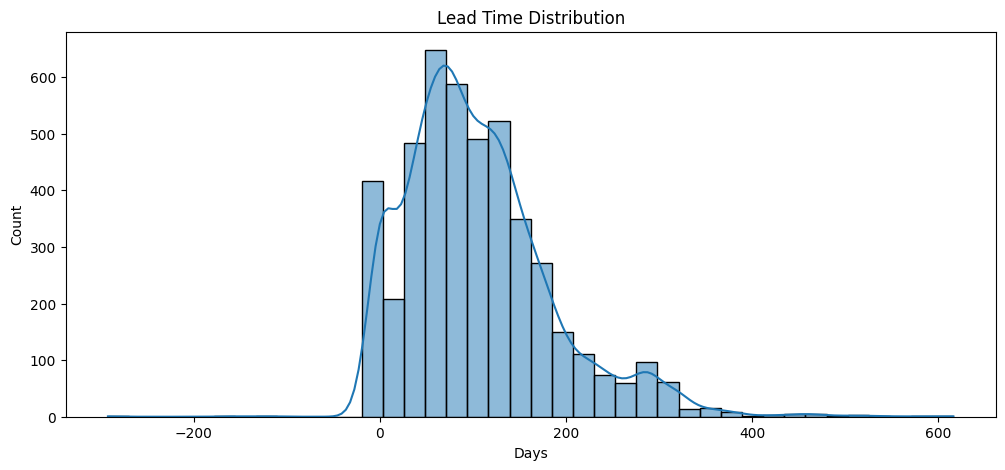

In [80]:
plt.figure(figsize=(12,5))
sns.histplot(fedex_df["lead_time"].dropna(), bins=40, kde=True)
plt.xlabel("Days")
plt.ylabel("Count")
plt.title("Lead Time Distribution")
plt.show()

**Chart - 2 Freight Cost Distribution**

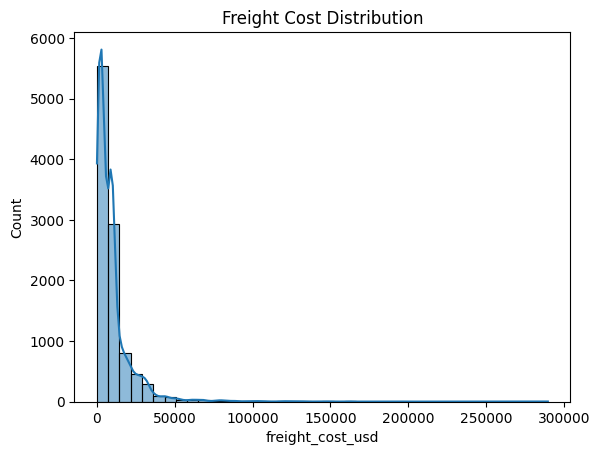

In [83]:
sns.histplot(fedex_df["freight_cost_usd"].dropna(), bins=40, kde=True)
plt.title("Freight Cost Distribution")
plt.show()

**Chart - 3 Freight Cost by Country (Top 10)**

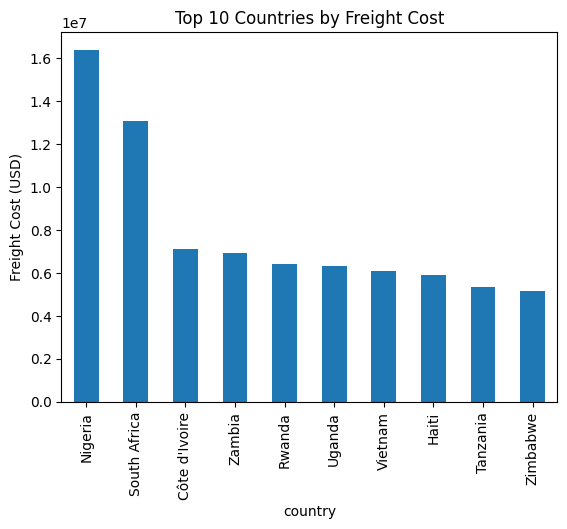

In [85]:
if 'country' in fedex_df.columns:
  top10 = fedex_df.groupby('country')['freight_cost_usd'].sum().sort_values(ascending=False).head(10)

  top10.plot(kind='bar')
  plt.title("Top 10 Countries by Freight Cost")
  plt.ylabel("Freight Cost (USD)")
  plt.show()

**Chart - 4 Lead Time By Shippment Mode**

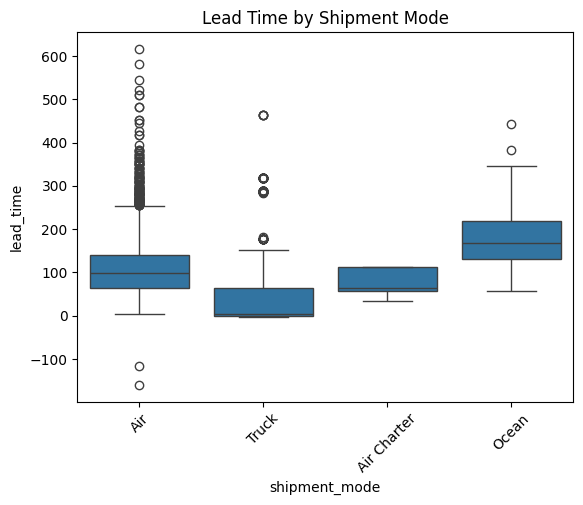

In [90]:
if "shipment_mode" in fedex_df.columns:
  sns.boxplot(x="shipment_mode", y="lead_time", data=fedex_df)
  plt.title("Lead Time by Shipment Mode")
  plt.xticks(rotation=45)
  plt.show()

**Chart - 5 Monthly On-Time Delivery Trend**

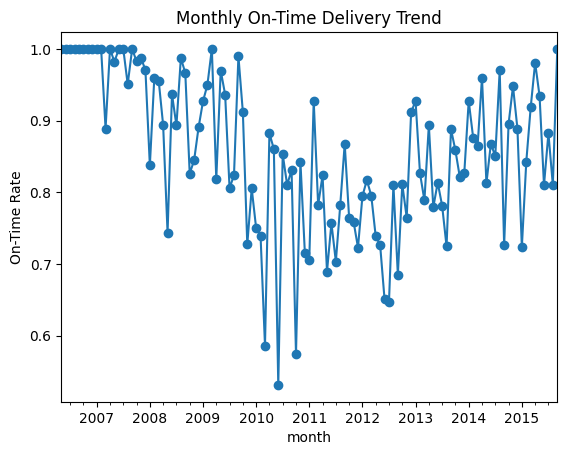

In [91]:
fedex_df['month'] = fedex_df['delivered_to_client_date'].dt.to_period('M')
monthly_ontime = fedex_df.groupby('month')['on_time_delivery'].mean()

monthly_ontime.plot(kind='line', marker='o')
plt.title("Monthly On-Time Delivery Trend")
plt.ylabel("On-Time Rate")
plt.show()

**Chart - 6 Correlation Heatmap**

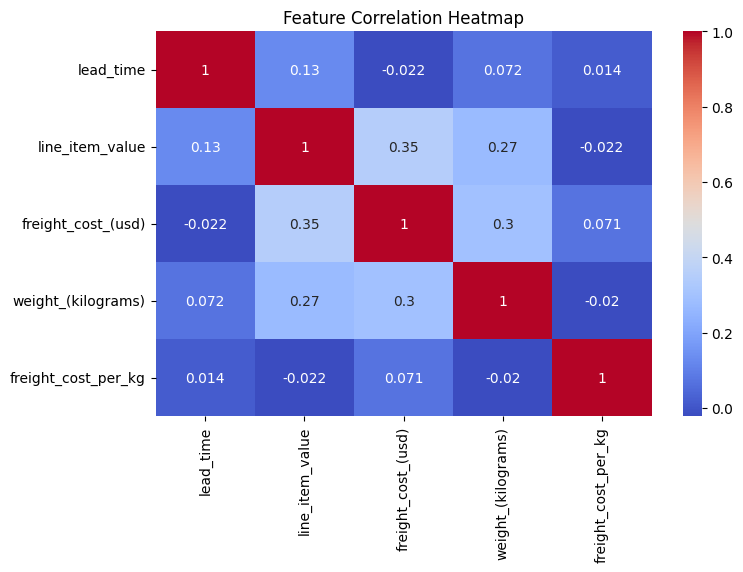

In [93]:
num_df = fedex_df[["lead_time","line_item_value","freight_cost_(usd)","weight_(kilograms)","freight_cost_per_kg"]]

plt.figure(figsize=(8, 5))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

**5. Solution to Business Objective**

What do you suggest the client to achieve Business Objective ?

Explain Briefly.

To achieve the business objective of improving logistics performance, the client should focus on optimizing shipment routes, prioritizing faster and more reliable transportation modes, and strengthening relationships with high-performing vendors. Continuous monitoring of key KPIs—such as lead time, on-time delivery rate, freight cost per kilogram, and shipment mode efficiency—will help identify operational gaps early. The client should also analyze freight cost drivers to reduce unnecessary spending and improve cost efficiency across regions. Implementing data-driven decision-making, improving shipment scheduling accuracy, and streamlining vendor coordination can further enhance end-to-end delivery performance. Overall, using insights from this analysis will enable FedEx to deliver shipments faster, more reliably, and at optimized costs.

**Conclusion**

This analysis provides a comprehensive view of FedEx’s logistics performance by examining key metrics such as lead time, freight cost, shipment mode efficiency, and on-time delivery trends. The findings highlight areas of operational strength as well as opportunities for improvement, particularly in optimizing transportation modes and reducing cost variability across regions. By understanding the factors that influence delivery delays and logistics expenses, FedEx can take targeted actions to enhance service reliability. The insights also show that improved shipment planning, vendor coordination, and cost monitoring can directly contribute to better performance outcomes. Overall, the project equips FedEx with actionable, data-driven recommendations to streamline its logistics network, reduce inefficiencies, and deliver a superior customer experience.

**Thank You!!!**